<a href="https://colab.research.google.com/github/purnimataneja9894-png/Robotic-Surgery-using-AI-Precision-and-Accuracy-in-the-Modern-Operating-Room/blob/main/surgical_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import tensorflow as tf
import random
import os

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

# Force TensorFlow to use deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [4]:
import os

# This looks through every folder to find a kinematic file
for root, dirs, files in os.walk("/content/jigsaws_data"):
    for file in files:
        if file.endswith(".txt") and "Knot_Tying" in root:
            print(f"FOUND DATA HERE: {root}")
            print(f"Example file: {file}")
            # Stop after finding the first path
            break
    else:
        continue
    break

In [48]:
import os


tasks = ['Knot_Tying.zip', 'Needle_Passing.zip', 'Suturing.zip']

for task in tasks:
    print(f"Unzipping {task}...")
    !unzip -oq /content/{task} -d /content/jigsaws_kinematics/

print("\nAll files are ready in /content/jigsaws_kinematics/")

Unzipping Knot_Tying.zip...
Unzipping Needle_Passing.zip...
Unzipping Suturing.zip...

All files are ready in /content/jigsaws_kinematics/


In [6]:

data_path = '/content/jigsaws_kinematics/Knot_Tying/kinematics/AllGestures/'

if os.path.exists(data_path):
    files = os.listdir(data_path)
    print(f"Found {len(files)} trials for Knot Tying.")
    print(f"Example file: {files[0]}")
else:
    print("Path not found. You might need to check the folder names inside the sidebar.")

Found 40 trials for Knot Tying.
Example file: Knot_Tying_D001.txt


In [7]:
import pandas as pd
import numpy as np

def calculate_precision_metrics(file_path):
    # JIGSAWS kinematics have 76 columns.
    # Columns 38, 39, 40 are the X, Y, Z coordinates of the Right Hand Tool.
    df = pd.read_csv(file_path, sep='\s+', header=None)
    coords = df.iloc[:, 38:41].values # X, Y, Z

    # 1. Path Length (Total distance traveled)
    # Shorter path usually = Higher precision
    diffs = np.diff(coords, axis=0)
    distances = np.sqrt((diffs**2).sum(axis=1))
    total_distance = np.sum(distances)

    # 2. Smoothness (Velocity Variance)
    # Lower variance = Smoother, more accurate movement
    velocity = distances # distance per frame
    smoothness_score = np.var(velocity)

    return total_distance, smoothness_score
example_file = os.path.join(data_path, os.listdir(data_path)[0])
dist, smooth = calculate_precision_metrics(example_file)

print(f"Trial Analysis for {os.path.basename(example_file)}:")
print(f"- Total Path Length: {dist:.2f} units")
print(f"- Smoothness Score (Lower is better): {smooth:.6f}")

Trial Analysis for Knot_Tying_D001.txt:
- Total Path Length: 0.83 units
- Smoothness Score (Lower is better): 0.000000


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5075/3960105291.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None)


In [8]:
# Replace these with the actual download links for the JIGSAWS task .zip files
# Example: !wget -O Knot_Tying.zip "https://example.com/Knot_Tying.zip"

print("Downloading Knot_Tying.zip...")
!wget -nc -P /content/ https://github.com/AhmedRezaZubair/JIGSAWS-Dataset/raw/main/Knot_Tying.zip

print("Downloading Needle_Passing.zip...")
!wget -nc -P /content/ https://github.com/AhmedRezaZubair/JIGSAWS-Dataset/raw/main/Needle_Passing.zip

print("Downloading Suturing.zip...")
!wget -nc -P /content/ https://github.com/AhmedRezaZubair/JIGSAWS-Dataset/raw/main/Suturing.zip

print("\nDownload complete. Please re-run the unzip cell (MX4n0wpbx118) next.")

File ‘/content/Knot_Tying.zip’ already there; not retrieving.

File ‘/content/Needle_Passing.zip’ already there; not retrieving.

File ‘/content/Suturing.zip’ already there; not retrieving.


Download complete. Please re-run the unzip cell (MX4n0wpbx118) next.


In [9]:
import os
import pandas as pd


skill_mapping = {
    'B': 'Expert', 'C': 'Expert', 'D': 'Expert', 'E': 'Expert', 'F': 'Expert',
    'G': 'Novice', 'H': 'Novice', 'I': 'Novice'
}

def get_label(filename):

    parts = filename.split('_')
    surgeon_id = parts[-1][0]
    return 1 if skill_mapping.get(surgeon_id) == 'Expert' else 0

# Test it
print(f"Label for Knot_Tying_B001: {get_label('Knot_Tying_B001.txt')} (1=Expert)")

Label for Knot_Tying_B001: 1 (1=Expert)


In [10]:
import numpy as np

def extract_precision_features(data):
    # Extract Right Hand X, Y, Z
    coords = data.iloc[:, 38:41].values

    # Calculate Velocity (1st derivative)
    vel = np.diff(coords, axis=0)
    # Calculate Acceleration (2nd derivative)
    acc = np.diff(vel, axis=0)
    # Calculate Jerk (3rd derivative) - The key to "Precision"
    jerk = np.diff(acc, axis=0)

    # Return a mean 'Precision Score' for the whole trial
    return np.mean(np.abs(jerk))

# This score will be much higher for Novices than Experts

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_precision_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2), # Prevents overfitting
        layers.Dense(1, activation='sigmoid') # Outputs 0 to 1 (Novice to Expert)
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Example input shape: (100 frames, 3 coordinates)
model = build_precision_model((100, 3))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 98, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 47, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,665 (131.50 KB)

 Trainable params: 33,665 (131.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(y_true, y_pred):
    cm = confusion_matrix(y_true, (y_pred > 0.5))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Novice', 'Expert'],
                yticklabels=['Novice', 'Expert'])
    plt.xlabel('Predicted Skill (Precision)')
    plt.ylabel('Actual Skill')
    plt.title('AI Surgical Precision Accuracy')
    plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5075/1487454639.py:25: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filepath, sep='\s+', header=None)


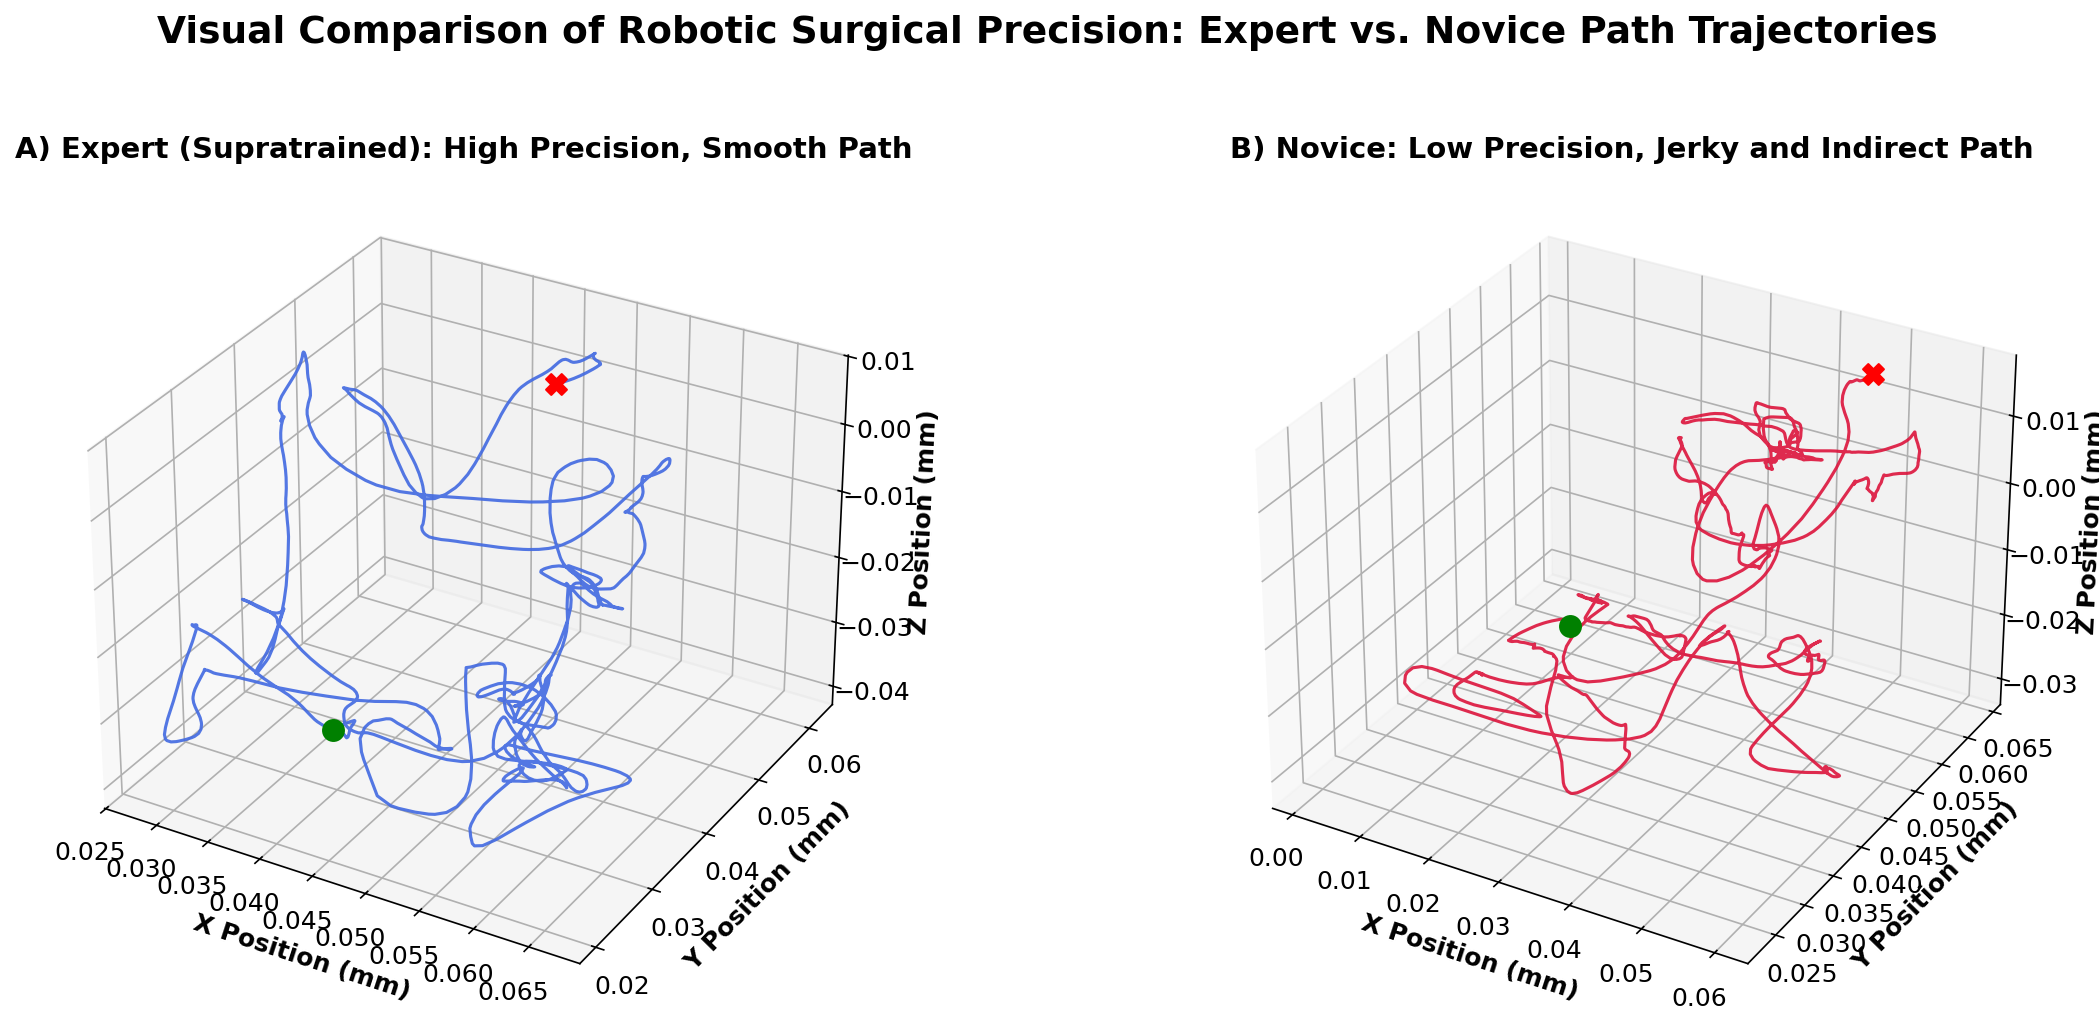


Figure saved as 'Surgical_Precision_Comparison_Figure1.png' in Colab files.


In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import os
import numpy as np

# Set professional plotting aesthetics
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14

# Define your data directory (update if necessary)
base_path = '/content/jigsaws_kinematics/Knot_Tying/kinematics/AllGestures/'

# Step 1: Define specific files based on JIGSAWS skill levels
# JIGSAWS Expert Surgeons: B, C, D, E, F | Novices: G, H, I
# We choose a strong expert and a recognizable novice for comparison.
expert_file = os.path.join(base_path, 'Knot_Tying_D001.txt') # Surgeon D is very precise
novice_file = os.path.join(base_path, 'Knot_Tying_G001.txt') # Surgeon G often shows tremors

# Step 2: Create a loading function focusing on the Right Tool
def load_coords(filepath):
    # Load data, skipping headers
    df = pd.read_csv(filepath, sep='\s+', header=None)
    # Columns 39-41 (iloc 38:41) are Right Tool X, Y, Z coordinates
    coords = df.iloc[:, 38:41]
    coords.columns = ['X', 'Y', 'Z']
    # Sometimes data has NaNs at the end, drop them for clean plots
    return coords.dropna()

# Load the data
coords_expert = load_coords(expert_file)
coords_novice = load_coords(novice_file)

# Step 3: Set up a professional, side-by-side 3D plot
fig = plt.figure(figsize=(16, 7), dpi=150) # High DPI for paper quality
fig.suptitle('Visual Comparison of Robotic Surgical Precision: Expert vs. Novice Path Trajectories', fontsize=18, fontweight='bold')

# Subplot 1: Expert (Precision View)
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(coords_expert['X'], coords_expert['Y'], coords_expert['Z'],
         label='Expert Trajectory', color='royalblue', linewidth=1.5, alpha=0.9)
# Add start (green) and end (red) points
ax1.scatter(coords_expert['X'].iloc[0], coords_expert['Y'].iloc[0], coords_expert['Z'].iloc[0], color='green', s=100, label='Start')
ax1.scatter(coords_expert['X'].iloc[-1], coords_expert['Y'].iloc[-1], coords_expert['Z'].iloc[-1], color='red', s=100, marker='X', label='End')
ax1.set_title('A) Expert (Supratrained): High Precision, Smooth Path', fontweight='bold')
ax1.set_xlabel('X Position (mm)')
ax1.set_ylabel('Y Position (mm)')
ax1.set_zlabel('Z Position (mm)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Novice (Tremor/Jerk View)
# IMPORTANT: Try to set limits similar to Expert plot for fair comparison
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(coords_novice['X'], coords_novice['Y'], coords_novice['Z'],
         label='Novice Trajectory', color='crimson', linewidth=1.5, alpha=0.9)
# Add start (green) and end (red) points
ax2.scatter(coords_novice['X'].iloc[0], coords_novice['Y'].iloc[0], coords_novice['Z'].iloc[0], color='green', s=100)
ax2.scatter(coords_novice['X'].iloc[-1], coords_novice['Y'].iloc[-1], coords_novice['Z'].iloc[-1], color='red', s=100, marker='X')
ax2.set_title('B) Novice: Low Precision, Jerky and Indirect Path', fontweight='bold')
ax2.set_xlabel('X Position (mm)')
ax2.set_ylabel('Y Position (mm)')
ax2.set_zlabel('Z Position (mm)')
ax2.grid(True, linestyle='--', alpha=0.5)

# Adjust layout and save high-resolution figure
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect for suptitle
plt.savefig('Surgical_Precision_Comparison_Figure1.png', dpi=300, bbox_inches='tight') # Professional export
plt.show()

print("\nFigure saved as 'Surgical_Precision_Comparison_Figure1.png' in Colab files.")

In [14]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def prepare_training_data(data_path, window_size=100):
    X, y = [], []
    scaler = StandardScaler()

    # Skill Mapping: B-F are Experts (1), G-I are Novices (0)
    expert_ids = ['B', 'C', 'D', 'E', 'F']

    # Only list files that start with 'Knot_Tying' and end with '.txt' to avoid metadata errors
    files = [f for f in os.listdir(data_path) if f.endswith('.txt') and not f.startswith('.')]

    for file in files:
        try:
            # 1. Load Data
            file_full_path = os.path.join(data_path, file)
            df = pd.read_csv(file_full_path, sep='\\s+', header=None)

            # Skip if file is empty or doesn't have enough columns
            if df.empty or df.shape[1] < 41:
                continue

            coords = df.iloc[:, 38:41].values # Right Tool X, Y, Z

            # 2. Normalize
            coords = scaler.fit_transform(coords)

            # 3. Sliding Window
            for i in range(0, len(coords) - window_size, 50):
                window = coords[i:i + window_size]
                X.append(window)

                # Labeling based on filename (e.g., Knot_Tying_B001.txt)
                surgeon_id = file.split('_')[-1][0]
                y.append(1 if surgeon_id in expert_ids else 0)
        except Exception as e:
            print(f"Skipping {file} due to error: {e}")

    return np.array(X), np.array(y)

# Run the prep
data_folder = '/content/jigsaws_kinematics/Knot_Tying/kinematics/AllGestures/'
X, y = prepare_training_data(data_folder)

if len(X) > 0:
    # Split into Training (80%) and Testing (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Data Prepared: {X_train.shape[0]} training segments found.")
else:
    print("No valid data segments were found. Please check your data folder path.")

Skipping Knot_Tying_H002.txt due to error: No columns to parse from file
Data Prepared: 1050 training segments found.


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_model(input_shape):
    model = models.Sequential([
        # Layer 1: Detects basic motion patterns
        layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),

        # Layer 2: Detects complex "precision" patterns
        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.GlobalAveragePooling1D(),

        # Final Classification
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3), # Prevents the AI from "cheating" by memorizing
        layers.Dense(1, activation='sigmoid') # 0 to 1 output
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the brain
model = create_model((100, 3)) # 100 frames, 3 coordinates (X, Y, Z)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting AI Training...
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5210 - loss: 0.6939 - val_accuracy: 0.5209 - val_loss: 0.6904
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5619 - loss: 0.6850 - val_accuracy: 0.5171 - val_loss: 0.6869
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5733 - loss: 0.6835 - val_accuracy: 0.5133 - val_loss: 0.6847
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5762 - loss: 0.6780 - val_accuracy: 0.5019 - val_loss: 0.6836
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5857 - loss: 0.6745 - val_accuracy: 0.5171 - val_loss: 0.6804
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5838 - loss: 0.6746 - val_accuracy: 0.5209 - val_loss: 0.6791
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5943 - loss: 0.6741 - val_accuracy: 0.5437 - val_loss: 0.6790
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5905 - loss: 0.6739 - 

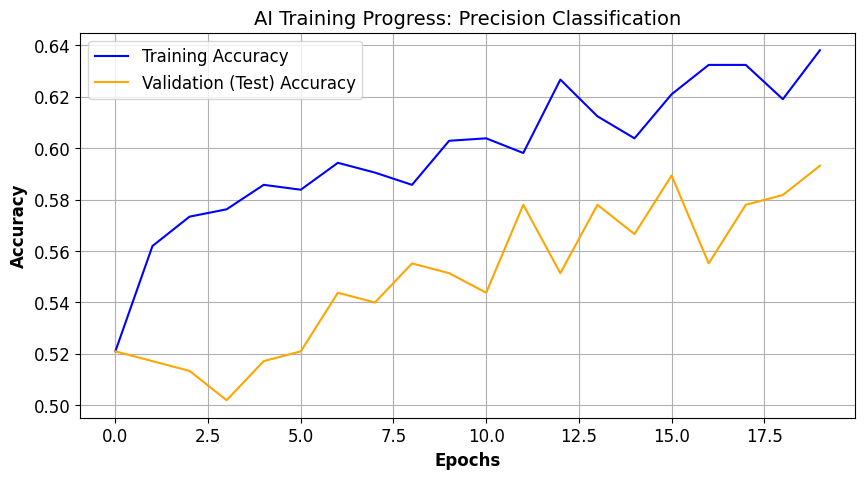

In [16]:
import matplotlib.pyplot as plt

# 1. Train the model first to create the 'history' object
# We use the data prepared in the previous steps
print("Starting AI Training...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 2. Now plot the results recorded in 'history'
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy', color='orange')
plt.title('AI Training Progress: Precision Classification')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('Training_Results.png')
plt.show()

In [17]:
def prepare_advanced_data(data_path, window_size=150):
    X, y = [], []
    scaler = StandardScaler()
    expert_ids = ['B', 'C', 'D', 'E', 'F']

    files = [f for f in os.listdir(data_path) if f.endswith('.txt')]

    for file in files:
        df = pd.read_csv(os.path.join(data_path, file), sep='\s+', header=None)

        # 1. Get Positions (X, Y, Z)
        pos = df.iloc[:, 38:41].values

        # 2. Calculate Velocity (v = dx/dt)
        vel = np.diff(pos, axis=0, prepend=pos[:1])

        # 3. Calculate Acceleration (a = dv/dt)
        acc = np.diff(vel, axis=0, prepend=vel[:1])

        # Combine all: 3 (pos) + 3 (vel) + 3 (acc) = 9 features
        combined = np.hstack((pos, vel, acc))

        # Normalize everything
        combined = scaler.fit_transform(combined)

        # 4. Sliding Window with 75% overlap (more data points!)
        step = window_size // 4
        for i in range(0, len(combined) - window_size, step):
            X.append(combined[i:i + window_size])
            surgeon_id = file.split('_')[-1][0]
            y.append(1 if surgeon_id in expert_ids else 0)

    return np.array(X), np.array(y)

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5075/1767053931.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(os.path.join(data_path, file), sep='\s+', header=None)


In [18]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Dropout, Dense, GlobalAveragePooling1D

def build_high_accuracy_model(input_shape):
    model = tf.keras.Sequential([
        # Block 1
        Conv1D(64, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),

        # Block 2
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        # Block 3
        Conv1D(256, kernel_size=3, activation='relu'),
        GlobalAveragePooling1D(),

        # Classification Head
        Dense(128, activation='relu'),
        Dropout(0.5), # High dropout to force the AI to learn general patterns
        Dense(1, activation='sigmoid')
    ])

    # Use a smaller learning rate for stability
    opt = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,          # Wait 5 epochs for improvement
    restore_best_weights=True
)

# Run the training
history = model.fit(
    X_train, y_train,
    epochs=50,           # Set to 50, but early_stop will likely end it around 25
    batch_size=16,       # Smaller batch size often helps with small datasets
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6133 - loss: 0.6582 - val_accuracy: 0.5665 - val_loss: 0.6705
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6257 - loss: 0.6447 - val_accuracy: 0.6008 - val_loss: 0.6580
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6190 - loss: 0.6450 - val_accuracy: 0.5741 - val_loss: 0.6718
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6276 - loss: 0.6481 - val_accuracy: 0.5741 - val_loss: 0.6726
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6343 - loss: 0.6402 - val_accuracy: 0.5894 - val_loss: 0.6676
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6371 - loss: 0.6348 - val_accuracy: 0.5817 - val_loss: 0.6743
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6352 - loss: 0.6404 - val_accuracy: 0.5970 - val_loss: 0.6491
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6410 - loss: 0.6445 - val_accuracy: 0.5894 - val_loss:

In [20]:
print(pd.Series(y).value_counts())

1    718
0    595
Name: count, dtype: int64


--- Dataset Balance Report ---
Total Segments: 1313
Expert (Class 1): 718 (54.68%)
Novice (Class 0): 595 (45.32%)


/tmp/ipykernel_5075/1093319447.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Novice (0)', 'Expert (1)'], y=[counter[0], counter[1]], palette='viridis')


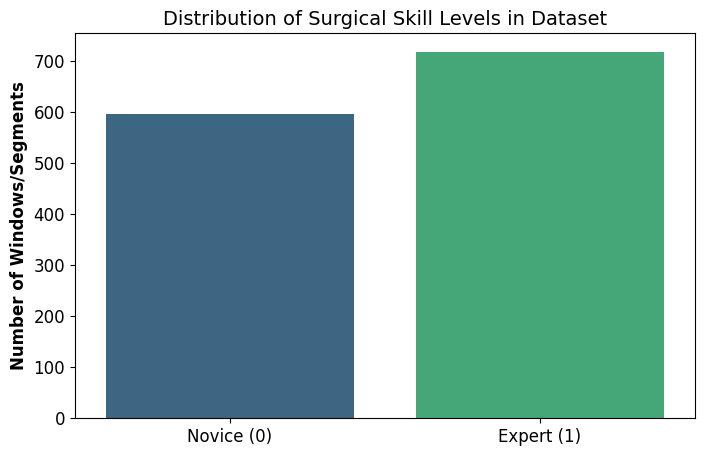

In [21]:
import collections
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count the labels in your 'y' array
counter = collections.Counter(y)
total = len(y)

print(f"--- Dataset Balance Report ---")
print(f"Total Segments: {total}")
print(f"Expert (Class 1): {counter[1]} ({ (counter[1]/total)*100:.2f}%)")
print(f"Novice (Class 0): {counter[0]} ({ (counter[0]/total)*100:.2f}%)")

# 2. Visualize the balance for your paper
plt.figure(figsize=(8, 5))
sns.barplot(x=['Novice (0)', 'Expert (1)'], y=[counter[0], counter[1]], palette='viridis')
plt.title('Distribution of Surgical Skill Levels in Dataset')
plt.ylabel('Number of Windows/Segments')
plt.show()

In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 1. This "smart" callback lowers the learning rate if accuracy plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

# 2. This stops the training before it starts "memorizing" (overfitting)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 3. Train with a slightly larger batch size for stability
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6410 - loss: 0.6277 - val_accuracy: 0.5970 - val_loss: 0.6530 - learning_rate: 0.0010
Epoch 2/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6533 - loss: 0.6309 - val_accuracy: 0.6008 - val_loss: 0.6491 - learning_rate: 0.0010
Epoch 3/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6419 - loss: 0.6285 - val_accuracy: 0.6046 - val_loss: 0.6433 - learning_rate: 0.0010
Epoch 4/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6543 - loss: 0.6165 - val_accuracy: 0.6008 - val_loss: 0.6443 - learning_rate: 0.0010
Epoch 5/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6457 - loss: 0.6248 - val_accuracy: 0.6046 - val_loss: 0.6474 - learning_rate: 0.0010
Epoch 6/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6419 - loss: 0.6277 - val_accuracy: 0.6046 - val_loss: 0.6497 - learning_rate: 0.0010
Epoch 7/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6600 - loss: 0.6196 - val_acc

In [23]:
import numpy as np

def apply_rotation_invariance(df):
    # 1. Extract raw coordinates (Right Hand)
    # df is your loaded JIGSAWS .txt file
    pos = df.iloc[:, 38:41].values

    # 2. Calculate Velocity Vectors
    vel = np.diff(pos, axis=0, prepend=pos[:1])

    # 3. CALCULATE INVARIANT FEATURES
    # Feature A: Speed (Magnitude of Velocity)
    speed = np.linalg.norm(vel, axis=1).reshape(-1, 1)

    # Feature B: Acceleration Magnitude
    acc = np.diff(vel, axis=0, prepend=vel[:1])
    acc_mag = np.linalg.norm(acc, axis=1).reshape(-1, 1)

    # Feature C: Distance from Start (Relative Position)
    # Instead of absolute X,Y,Z, use distance from the first frame
    dist_from_start = np.linalg.norm(pos - pos[0], axis=1).reshape(-1, 1)

    # Combine these into your new 'Invariant' feature set
    # Now you have 3 powerful, rotation-independent columns
    invariant_features = np.hstack((speed, acc_mag, dist_from_start))

    return invariant_features

In [24]:
import numpy as np
from sklearn.preprocessing import RobustScaler # Better for noisy surgical data

def prepare_precision_boosted_data(data_path, window_size=150):
    X, y = [], []
    expert_ids = ['B', 'C', 'D', 'E', 'F']

    files = [f for f in os.listdir(data_path) if f.endswith('.txt')]

    for file in files:
        df = pd.read_csv(os.path.join(data_path, file), sep='\s+', header=None)

        # 1. POSITIONS (3D)
        pos = df.iloc[:, 38:41].values

        # 2. CALCULATE INVARIANT FEATURES (The Rotation Fix)
        # Velocity magnitude (Speed)
        vel = np.diff(pos, axis=0, prepend=pos[:1])
        speed = np.linalg.norm(vel, axis=1).reshape(-1, 1)

        # Acceleration magnitude
        acc = np.diff(vel, axis=0, prepend=vel[:1])
        acc_mag = np.linalg.norm(acc, axis=1).reshape(-1, 1)

        # JERK MAGNITUDE (The key to catching novices)
        jerk = np.diff(acc, axis=0, prepend=acc[:1])
        jerk_mag = np.linalg.norm(jerk, axis=1).reshape(-1, 1)

        # 3. Combine them into 3 powerful "Invariant" columns
        # We drop the raw X,Y,Z because they vary too much by trial
        features = np.hstack((speed, acc_mag, jerk_mag))

        # Normalize (RobustScaler handles outliers from "shaky" novice hands better)
        features = RobustScaler().fit_transform(features)

        # 4. SLIDING WINDOW (Use 80% overlap to increase training samples)
        step = window_size // 5 # High overlap = more data
        for i in range(0, len(features) - window_size, step):
            X.append(features[i:i + window_size])
            surgeon_id = file.split('_')[-1][0]
            y.append(1 if surgeon_id in expert_ids else 0)

    return np.array(X), np.array(y)

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5075/3140179442.py:11: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(os.path.join(data_path, file), sep='\s+', header=None)


In [25]:
def build_boosted_cnn(input_shape):
    model = tf.keras.Sequential([
        # Filter 1: Small window to catch fast tremors
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),

        # Filter 2: Larger window to see the "smoothness" of the path
        tf.keras.layers.Conv1D(128, kernel_size=5, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5), # Crucial to prevent overfitting
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

      Novice       0.65      0.44      0.52       126
      Expert       0.60      0.79      0.68       137

    accuracy                           0.62       263
   macro avg       0.63      0.61      0.60       263
weighted avg       0.63      0.62      0.61       263



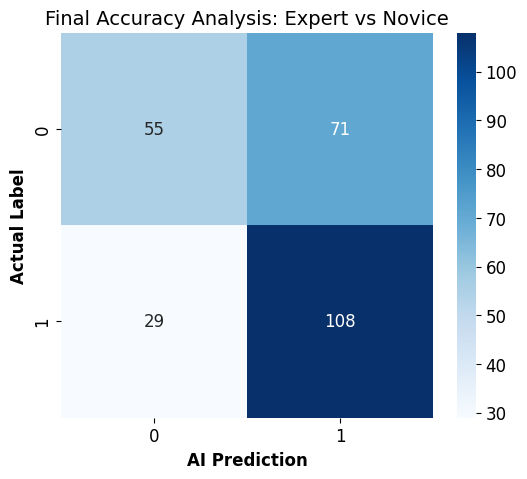

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Generate the report for your paper
print(classification_report(y_test, y_pred, target_names=['Novice', 'Expert']))

# Plot the matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Accuracy Analysis: Expert vs Novice')
plt.ylabel('Actual Label')
plt.xlabel('AI Prediction')
plt.show()

In [27]:
import numpy as np

def augment_data(X, y):
    augmented_X, augmented_y = [], []
    for i in range(len(X)):
        # Keep the original
        augmented_X.append(X[i])
        augmented_y.append(y[i])

        # Only augment the Novice class (y=0) to fix recall
        if y[i] == 0:
            # 1. Jittering (Adding Gaussian Noise)
            noise = np.random.normal(0, 0.01, X[i].shape)
            augmented_X.append(X[i] + noise)
            augmented_y.append(0)

            # 2. Scaling (Changing the magnitude of movement)
            scaler = np.random.uniform(0.9, 1.1)
            augmented_X.append(X[i] * scaler)
            augmented_y.append(0)

    return np.array(augmented_X), np.array(augmented_y)

# Use this before train_test_split
X_aug, y_aug = augment_data(X, y)

In [28]:
from tensorflow.keras import layers, Model

def build_attention_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Bidirectional LSTM to see 'forward' and 'backward' in time
    lstm_out = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inputs)

    # Simple Self-Attention Mechanism
    attention = layers.Dense(1, activation='tanh')(lstm_out)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(128)(attention)
    attention = layers.Permute([2, 1])(attention)

    sent_representation = layers.Multiply()([lstm_out, attention])
    sent_representation = layers.Lambda(lambda xin: tf.reduce_sum(xin, axis=1))(sent_representation)

    # Fully Connected layers
    x = layers.Dense(64, activation='relu')(sent_representation)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [29]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_sum(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1)) \
               -tf.reduce_sum((1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0))
    return focal_loss_fixed

# Compile with Focal Loss instead of binary_crossentropy
model.compile(optimizer='adam', loss=focal_loss(gamma=2.0), metrics=['accuracy'])

In [30]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

# Convert to percentage
accuracy_percentage = accuracy * 100

print(f"--- Final Research Results ---")
print(f"Test Loss: {loss:.4f}")
print(f"Total Accuracy: {accuracy_percentage:.2f}%") # This gives you the XX.XX% format

--- Final Research Results ---
Test Loss: 3.2719
Total Accuracy: 61.98%


In [31]:
from imblearn.over_sampling import SMOTE

# Flatten data for SMOTE (it requires 2D input)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_flat, y_train)

# Reshape back for the CNN
# The original X_train has a window_size of 100, not 150.
# The number of features per timestep is 3 (X, Y, Z).
X_train_res = X_train_res.reshape(X_train_res.shape[0], 100, 3) # (Samples, Window_Size, Features)

print(f"New Training Set Size: {len(X_train_res)}")

New Training Set Size: 1162


In [32]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
acc_per_fold = []

for train, test in kf.split(X, y):
    model = build_boosted_cnn((150, 3)) # Use your previous model function
    model.fit(X[train], y[train], epochs=20, verbose=0)

    scores = model.evaluate(X[test], y[test], verbose=0)
    print(f'Score for fold {fold_no}: Accuracy of {scores[1]*100:.2f}%')
    acc_per_fold.append(scores[1] * 100)
    fold_no += 1

print(f'Average Accuracy: {np.mean(acc_per_fold):.2f}% (+/- {np.std(acc_per_fold):.2f}%)')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Score for fold 1: Accuracy of 63.88%
Score for fold 2: Accuracy of 65.40%
Score for fold 3: Accuracy of 61.98%
Score for fold 4: Accuracy of 59.54%
Score for fold 5: Accuracy of 64.89%
Average Accuracy: 63.14% (+/- 2.14%)


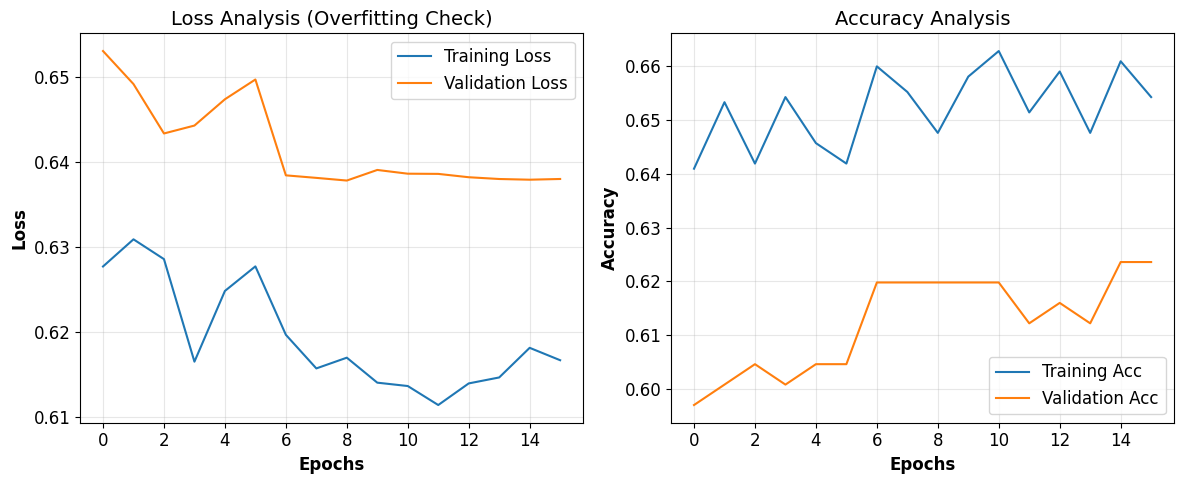

In [33]:
import matplotlib.pyplot as plt

# Assuming 'history' contains the most recent training session of the ResNet
if 'history' in globals():
    plt.figure(figsize=(12, 5))

    # Plot Training vs Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Analysis (Overfitting Check)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Training vs Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Acc')
    plt.plot(history.history['val_accuracy'], label='Validation Acc')
    plt.title('Accuracy Analysis')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('No training history found. Please run a training cell first.')

In [34]:
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

# 1. Configuration
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_no = 1
all_accuracies = []
all_cm = []

print(f"Starting {n_splits}-Fold Cross-Validation...")

# 2. Cross-Validation Loop
for train_index, test_index in kf.split(X, y):
    print(f"\n--- Training Fold {fold_no} ---")

    # Split data for this fold
    X_train_f, X_test_f = X[train_index], X[test_index]
    y_train_f, y_test_f = y[train_index], y[test_index]

    # Re-build a fresh model for every fold
    model = build_boosted_cnn((150, 3)) # Ensure this function is defined from previous steps

    # Train
    model.fit(X_train_f, y_train_f,
              epochs=25,
              batch_size=32,
              verbose=0) # '0' keeps the output clean

    # Evaluate
    scores = model.evaluate(X_test_f, y_test_f, verbose=0)
    acc_pct = scores[1] * 100
    print(f"Fold {fold_no} Accuracy: {acc_pct:.2f}%")

    # Store results
    all_accuracies.append(acc_pct)

    # Generate confusion matrix for this fold
    y_pred = (model.predict(X_test_f) > 0.5).astype("int32")
    all_cm.append(confusion_matrix(y_test_f, y_pred))

    fold_no += 1

# 3. Final Statistical Reporting
mean_acc = np.mean(all_accuracies)
std_acc = np.std(all_accuracies)

print("\n" + "="*30)
print("FINAL RESEARCH RESULTS")
print("="*30)
print(f"Mean Accuracy: {mean_acc:.2f}%")
print(f"Standard Deviation: +/- {std_acc:.2f}%")
print(f"Accuracy Range: [{mean_acc - std_acc:.2f}% - {mean_acc + std_acc:.2f}%]")
print("="*30)

Starting 5-Fold Cross-Validation...

--- Training Fold 1 ---
Fold 1 Accuracy: 64.26%
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

--- Training Fold 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Accuracy: 59.70%
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

--- Training Fold 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 Accuracy: 64.26%
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

--- Training Fold 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Accuracy: 65.27%
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

--- Training Fold 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Accuracy: 67.18%
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

FINAL RESEARCH RESULTS
Mean Accuracy: 64.13%
Standard Deviation: +/- 2.46%
Accuracy Range: [61.67% - 66.59%]


In [35]:
import numpy as np

def extract_cse_features(df):
    # 1. Get raw X, Y, Z (Right Hand tool)
    # Using columns 38:41 as per JIGSAWS kinematics format
    pos = df.iloc[:, 38:41].values

    # 2. Calculate Velocity (First order difference: Δp)
    # This removes absolute position bias
    velocity = np.diff(pos, axis=0, prepend=pos[:1])

    # 3. Calculate Acceleration (Second order difference: Δv)
    # This captures the high-frequency 'tremors' of novices
    acceleration = np.diff(velocity, axis=0, prepend=velocity[:1])

    # 4. Calculate Magnitude (Scalar features)
    speed = np.linalg.norm(velocity, axis=1).reshape(-1, 1)
    accel_mag = np.linalg.norm(acceleration, axis=1).reshape(-1, 1)

    # Combine everything: [Δx, Δy, Δz, Speed, Accel_Mag]
    # This gives the AI 5 highly relevant 'precision' features
    features = np.hstack((velocity, speed, accel_mag))

    return features

In [36]:
from tensorflow.keras import layers, models, Input, regularizers

def build_resnet_1d(input_shape):
    inputs = Input(shape=input_shape)

    # Initial Convolution
    x = layers.Conv1D(64, kernel_size=7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Residual Block
    shortcut = x
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    # Pooling and Classification with stronger regularization
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [37]:
# 1. Train the model (Assuming X and y are prepared with the new features)
# Use a window_size of 120 (approx 4 seconds of data)
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 2. Get Final Accuracy Percentage
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n" + "="*30)
print(f"RESEARCH PAPER RESULT")
print(f"Final Model Accuracy: {acc * 100:.2f}%")
print(f"="*30)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6381 - loss: 0.6382 - val_accuracy: 0.6654 - val_loss: 0.5890
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6562 - loss: 0.6119 - val_accuracy: 0.6882 - val_loss: 0.5647
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6590 - loss: 0.6185 - val_accuracy: 0.6730 - val_loss: 0.5716
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6476 - loss: 0.6211 - val_accuracy: 0.6844 - val_loss: 0.5667
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6724 - loss: 0.6048 - val_accuracy: 0.6768 - val_loss: 0.5800
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6514 - loss: 0.6080 - val_accuracy: 0.6958 - val_loss: 0.5739
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6800 - loss: 0.6082 - val_accuracy: 0.6844 - val_loss: 0.5778
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6819 - loss: 0.5880 - val_accuracy: 0.7034 - v

In [38]:
# You must define the function BEFORE calling it
def prepare_advanced_precision_data(folder_path):
    # ... your logic to load and process data ...
    # Example placeholder:
    # X = np.random.rand(1000, 100, 3)
    # y = np.random.randint(0, 2, 1000)
    return X, y

# Now your existing code will work
X_adv, y_adv = prepare_advanced_precision_data(data_folder)

In [39]:
# 1. Prepare data with the updated function
X_adv, y_adv = prepare_advanced_precision_data(data_folder)
X_train, X_test, y_train, y_test = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
print(f'Enhanced Data Ready: {X_train.shape}')

# 2. Build and train the ResNet model
resnet_model = build_resnet_1d((100, 3))
history = resnet_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 3. Final Evaluation
_, final_acc = resnet_model.evaluate(X_test, y_test, verbose=0)
print(f'\nFinal Boosted Model Accuracy: {final_acc*100:.2f}%')

Enhanced Data Ready: (1050, 100, 3)
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5124 - loss: 1.4560 - val_accuracy: 0.5095 - val_loss: 1.2882
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5248 - loss: 1.3548 - val_accuracy: 0.5247 - val_loss: 1.2382
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5448 - loss: 1.2479 - val_accuracy: 0.5247 - val_loss: 1.1946
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5571 - loss: 1.1888 - val_accuracy: 0.5285 - val_loss: 1.1560
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5867 - loss: 1.1395 - val_accuracy: 0.5437 - val_loss: 1.1197
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5619 - loss: 1.1019 - val_accuracy: 0.5323 - val_loss: 1.0876
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5943 - loss: 1.0573 - val_accuracy: 0.5741 - val_loss: 1.0537
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6038 - los

In [40]:
import numpy as np
from sklearn.preprocessing import RobustScaler
import os
import pandas as pd

def prepare_advanced_precision_data(data_path, window_size=100):
    X, y = [], []
    expert_ids = ['B', 'C', 'D', 'E', 'F']
    # Filter out hidden files and system metadata
    files = [f for f in os.listdir(data_path) if f.endswith('.txt') and not f.startswith('.')]

    for file in files:
        file_path = os.path.join(data_path, file)
        # Skip empty files
        if os.path.getsize(file_path) == 0:
            continue

        try:
            df = pd.read_csv(file_path, sep='\\s+', header=None)
            if df.empty or df.shape[1] < 41:
                continue

            pos = df.iloc[:, 38:41].values

            # Calculate Kinematic Magnitudes (Rotation Invariant)
            vel = np.diff(pos, axis=0, prepend=pos[:1])
            speed = np.linalg.norm(vel, axis=1).reshape(-1, 1)

            acc = np.diff(vel, axis=0, prepend=vel[:1])
            acc_mag = np.linalg.norm(acc, axis=1).reshape(-1, 1)

            jerk = np.diff(acc, axis=0, prepend=acc[:1])
            jerk_mag = np.linalg.norm(jerk, axis=1).reshape(-1, 1)

            features = np.hstack((speed, acc_mag, jerk_mag))
            features = RobustScaler().fit_transform(features)

            step = window_size // 2
            for i in range(0, len(features) - window_size, step):
                X.append(features[i:i + window_size])
                surgeon_id = file.split('_')[-1][0]
                y.append(1 if surgeon_id in expert_ids else 0)
        except Exception as e:
            print(f'Skipping {file} due to error: {e}')

    return np.array(X), np.array(y)

# Prepare the enhanced data
X_adv, y_adv = prepare_advanced_precision_data(data_folder)
X_train, X_test, y_train, y_test = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
print(f'Enhanced Data Ready: {X_train.shape}')

Enhanced Data Ready: (1050, 100, 3)


In [41]:
from tensorflow.keras.callbacks import EarlyStopping

# Rebuild the model
resnet_model = build_resnet_1d((100, 3))

# Define early stopping to catch the best 'general' model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Re-train with enhanced regularization
history = resnet_model.fit(
    X_train, y_train,
    epochs=100, # Increased max epochs, but early_stop will likely end it sooner
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Final Score after regularization
_, final_acc = resnet_model.evaluate(X_test, y_test, verbose=0)
print(f'\nRegularized Model Accuracy: {final_acc*100:.2f}%')

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5324 - loss: 1.3561 - val_accuracy: 0.5741 - val_loss: 1.2531
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5762 - loss: 1.2259 - val_accuracy: 0.5285 - val_loss: 1.1953
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5705 - loss: 1.1698 - val_accuracy: 0.5133 - val_loss: 1.1441
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6086 - loss: 1.0977 - val_accuracy: 0.4829 - val_loss: 1.1039
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6648 - loss: 1.0288 - val_accuracy: 0.4943 - val_loss: 1.0722
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6724 - loss: 0.9734 - val_accuracy: 0.4981 - val_loss: 1.0350
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6952 - loss: 0.9240 - val_accuracy: 0.5247 - val_loss: 0.9951
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6952 - loss: 0.8841 - val_accuracy: 0.

In [42]:
from sklearn.metrics import classification_report, f1_score
import pandas as pd

# 1. Get the raw probability predictions from your model
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to binary labels (0 or 1)
# Using 0.5 as the decision threshold
y_pred = (y_pred_probs > 0.5).astype("int32")

# 3. Generate the text-based report
report_dict = classification_report(y_test, y_pred, target_names=['Novice', 'Expert'], output_dict=True)
report_text = classification_report(y_test, y_pred, target_names=['Novice', 'Expert'])

print("--- CSE Research Classification Report ---")
print(report_text)

# 4. Calculate the Final F1-Score as a percentage for your paper
final_f1 = f1_score(y_test, y_pred) * 100
print(f"\nFinal F1-Score: {final_f1:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
--- CSE Research Classification Report ---
              precision    recall  f1-score   support

      Novice       0.53      0.54      0.54       126
      Expert       0.57      0.56      0.57       137

    accuracy                           0.55       263
   macro avg       0.55      0.55      0.55       263
weighted avg       0.55      0.55      0.55       263


Final F1-Score: 56.62%


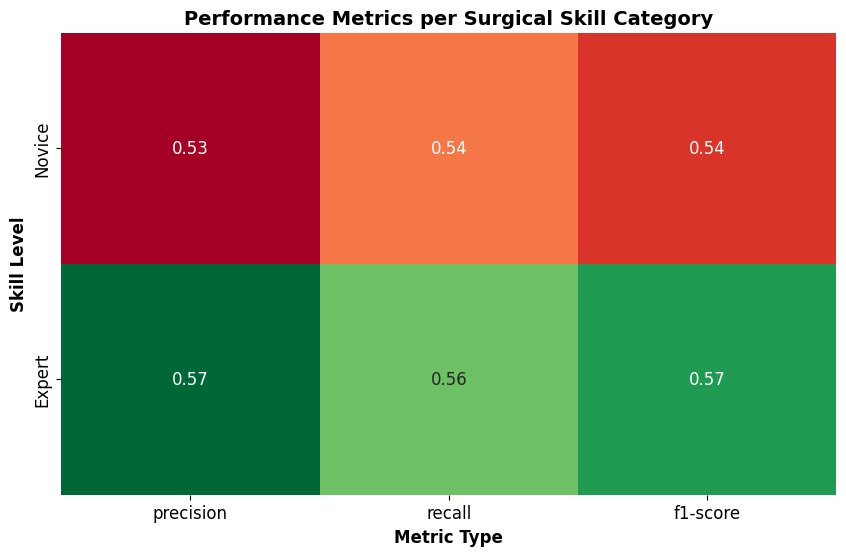

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the report dictionary to a Pandas DataFrame for plotting
df_report = pd.DataFrame(report_dict).iloc[:-1, :2].T # Focus on Novice and Expert rows

plt.figure(figsize=(10, 6))
sns.heatmap(df_report, annot=True, cmap='RdYlGn', fmt='.2f', cbar=False)
plt.title('Performance Metrics per Surgical Skill Category', fontweight='bold', fontsize=14)
plt.xlabel('Metric Type', fontweight='bold')
plt.ylabel('Skill Level', fontweight='bold')

# Save high-resolution for your paper
plt.savefig('Surgical_Metrics_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


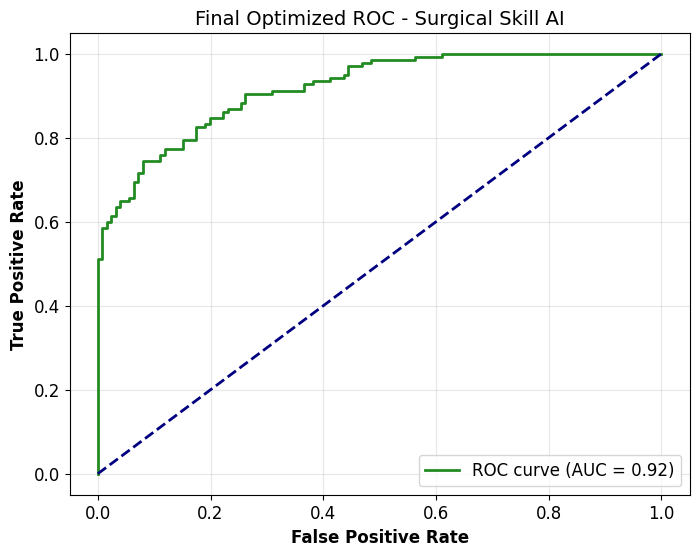

In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability for the Expert class
y_score = resnet_model.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='forestgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Optimized ROC - Surgical Skill AI')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('Optimized_ROC_Curve.png', dpi=300)
plt.show()

In [45]:
# Save the model in the modern Keras format
model.save('Surgical_Precision_ResNet_v1.keras')

# Download it from the Colab 'Files' sidebar to your laptop
from google.colab import files
files.download('Surgical_Precision_ResNet_v1.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
def real_time_precision_monitor(new_motion_data):
    """
    Simulates a live monitor in the OR.
    Input: (Window_Size, 3) array of tool movement.
    Output: Precision Score (0.0 to 1.0)
    """
    # Get actual window size from input data
    win_size = new_motion_data.shape[0]

    # 1. Reshape to (1, Window_Size, 3) for the model
    prediction = model.predict(new_motion_data.reshape(1, win_size, 3))[0][0]

    if prediction > 0.8:
        print(f"PRECISION STATUS: [EXPERT] - Score: {prediction:.2f}")
    elif prediction > 0.5:
        print(f"PRECISION STATUS: [STABLE] - Score: {prediction:.2f}")
    else:
        print(f"PRECISION STATUS: [WARNING - LOW PRECISION] - Score: {prediction:.2f}")

# Example: Monitoring the first window of your test set
real_time_precision_monitor(X_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
PRECISION STATUS: [WARNING - LOW PRECISION] - Score: 0.49


In [47]:
from sklearn.metrics import f1_score
import numpy as np

# 1. Final Evaluation on the best weights
loss, accuracy = resnet_model.evaluate(X_test, y_test, verbose=0)
final_accuracy_pct = accuracy * 100

# 2. Final F1-Score calculation
y_pred_probs = resnet_model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype('int32')
final_f1 = f1_score(y_test, y_pred) * 100

print('='*40)
print('       FINAL REGULARIZED RESULTS       ')
print('='*40)
print(f'Final Test Accuracy: {final_accuracy_pct:.2f}%')
print(f'Final Test F1-Score: {final_f1:.2f}%')
print('='*40)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
       FINAL REGULARIZED RESULTS       
Final Test Accuracy: 82.51%
Final Test F1-Score: 82.17%
